# FAPE, FairGround Corpus EDA
## Multi-Domain Benchmark Analysis

**Corpus:** FairGround, Simson et al. (2025)  
**Datasets loaded:** 36 of 38 (law_school_tensorflow and stop_question_and_frisk_data fail because fairml-datasets 0.2.5 calls np.bool, which numpy 1.26 does not have)  
**Total records:** 1,955,063 (1,964,010 when a cached copy of stop_question_and_frisk_data is present)  
**Domains:** Criminal justice, financial, healthcare, education, socioeconomic, other/synthetic  

FairGround addresses the benchmark monoculture problem identified by Ding et al. (2021), pre-validated sensitive attribute metadata eliminates arbitrary preprocessing choices.

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import pandas as pd
import logging
logging.getLogger('fairml_datasets').setLevel(logging.WARNING)   # its INFO logs link to local file paths
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from fairground_loader import load_fairground_corpus

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

os.makedirs('../figures/eda', exist_ok=True)
print('Imports complete')

Imports complete


In [2]:
corpus = load_fairground_corpus()

def get_domain(name):
    if any(x in name for x in ['compas','stop_question','chicago','ricci']):
        return 'Criminal Justice'
    elif any(x in name for x in ['credit','bank']):
        return 'Financial'
    elif any(x in name for x in ['meps','heart','arrhythmia']):
        return 'Healthcare'
    elif any(x in name for x in ['student','law_school','nursery']):
        return 'Education'
    elif any(x in name for x in ['adult','folktables','dutch','communities']):
        return 'Socioeconomic'
    else:
        return 'Other/Synthetic'

def get_balance(rate):
    if rate is None or pd.isna(rate):
        return 'No rate computed'
    elif rate < 0 or rate > 1:
        return 'Non-binary target'
    elif 0.3 <= rate <= 0.7:
        return 'Balanced (30-70%)'
    else:
        return 'Imbalanced'

rows = []
for k, v in corpus.items():
    meta = v['metadata']
    rows.append({
        'dataset': k,
        'n_samples': meta['n_samples'],
        'n_features': meta['n_features'],
        'sensitive_cols': meta['sensitive_columns'],
        'positive_rate': meta['positive_rate'],
        'domain': get_domain(k),
        'balance': get_balance(meta['positive_rate'])
    })
df = pd.DataFrame(rows)

DOMAIN_ORDER = ['Criminal Justice','Financial','Healthcare','Education','Socioeconomic','Other/Synthetic']
DOMAIN_COLORS = dict(zip(DOMAIN_ORDER, sns.color_palette('muted', 6)))

print(f'Datasets: {len(df)} | Total records: {df["n_samples"].sum():,}')
print(df['domain'].value_counts())

FairGround corpus: 38 datasets available
  OK: adult: 32,560 rows | 14 features | sensitive: ['race']
  OK: arrhythmia: 451 rows | 279 features | sensitive: ['sex']
  OK: bank_additional_full: 41,188 rows | 20 features | sensitive: ['age']
  OK: bank_additional: 4,119 rows | 20 features | sensitive: ['age', 'marital']
  OK: bank_full: 45,211 rows | 16 features | sensitive: ['age', 'marital']
  OK: bank: 4,521 rows | 16 features | sensitive: ['age']
  OK: communities: 1,993 rows | 127 features | sensitive: ['racePctAsian']


  OK: communities_unnormalized: 2,214 rows | 146 features | sensitive: ['pct12-21']
  OK: compas_2_years: 6,172 rows | 52 features | sensitive: ['age']
  OK: compas_2_years_violent: 4,743 rows | 53 features | sensitive: ['age']
  OK: compas: 11,757 rows | 46 features | sensitive: ['sex', 'age']
  OK: creditcard: 30,000 rows | 24 features | sensitive: ['SEX']
  OK: drug: 1,885 rows | 31 features | sensitive: ['ethnicity']
  OK: dutch: 60,420 rows | 11 features | sensitive: ['age']
  OK: german_credit: 1,000 rows | 20 features | sensitive: ['foreign_worker']
  OK: german_credit_numeric: 1,000 rows | 24 features | sensitive: ['age']
  OK: south_german_credit: 1,000 rows | 20 features | sensitive: ['age', 'foreign_worker']
  OK: german_credit_onehot: 1,000 rows | 64 features | sensitive: ['<= 25 years']
  OK: heart_disease: 303 rows | 13 features | sensitive: ['sex']
  FAIL: law_school_tensorflow: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the
  OK: law_sc

  OK: meps_panel_19_fy2015: 15,830 rows | 1830 features | sensitive: ['RACE']


  OK: meps_panel_20_fy2015: 17,570 rows | 1830 features | sensitive: ['RACE']


  OK: meps_panel_21_fy2016: 15,675 rows | 1940 features | sensitive: ['RACE']
  OK: nursery: 12,960 rows | 8 features | sensitive: ['finance']
  OK: ricci: 118 rows | 4 features | sensitive: ['Race']
  FAIL: stop_question_and_frisk_data: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the


  OK: chicago_strategic_subject_list: 398,684 rows | 47 features | sensitive: ['RACE CODE CD']
  OK: student: 395 rows | 32 features | sensitive: ['sex']
  OK: student_language: 649 rows | 32 features | sensitive: ['age']
  OK: generate_synthetic_data: 2,000 rows | 3 features | sensitive: ['s1']
  OK: lipton_synthetic_hiring_dataset: 2,000 rows | 3 features | sensitive: ['sex']
  OK: synth: 6,400 rows | 3 features | sensitive: ['sensible_feature']
  OK: folktables_acsincome_small: 245,673 rows | 10 features | sensitive: ['RAC1P']
  OK: folktables_acspubliccoverage_small: 174,178 rows | 19 features | sensitive: ['RAC1P']
  OK: folktables_acsmobility_small: 98,081 rows | 21 features | sensitive: ['RAC1P']
  OK: folktables_acsemployment_small: 478,236 rows | 16 features | sensitive: ['RAC1P']


  OK: folktables_acstraveltime_small: 216,385 rows | 16 features | sensitive: ['RAC1P']

FairGround load complete:
  Loaded:  36 datasets
  Failed:  2 datasets
  Records: 1,955,063 total

Failed datasets:
  law_school_tensorflow: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the
  stop_question_and_frisk_data: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the
Datasets: 36 | Total records: 1,955,063
domain
Socioeconomic       9
Financial           9
Healthcare          5
Criminal Justice    5
Other/Synthetic     4
Education           4
Name: count, dtype: int64


## 1. Dataset Sizes, All 36 Loaded Datasets

In [3]:
df_sorted = df.sort_values('n_samples', ascending=True)

fig, ax = plt.subplots(figsize=(12, 14))
colors = [DOMAIN_COLORS[d] for d in df_sorted['domain']]
bars = ax.barh(df_sorted['dataset'], df_sorted['n_samples'],
               color=colors, edgecolor='black', linewidth=0.3)
ax.set_xscale('log')
ax.set_title(f'FairGround Dataset Sizes (log scale) - {len(df)} Datasets', fontsize=14, pad=15)
ax.set_xlabel('Number of Records (log scale)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
for bar, val in zip(bars, df_sorted['n_samples']):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=DOMAIN_COLORS[d], label=d) for d in DOMAIN_ORDER]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_dataset_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Largest: {df.loc[df["n_samples"].idxmax(), "dataset"]}, {df["n_samples"].max():,}')
print(f'Smallest: {df.loc[df["n_samples"].idxmin(), "dataset"]}, {df["n_samples"].min():,}')
print(f'Median: {df["n_samples"].median():,.0f}')

<Figure size 1200x1400 with 1 Axes>

Largest: folktables_acsemployment_small, 478,236
Smallest: ricci, 118
Median: 6,286


## 2. Domain Coverage

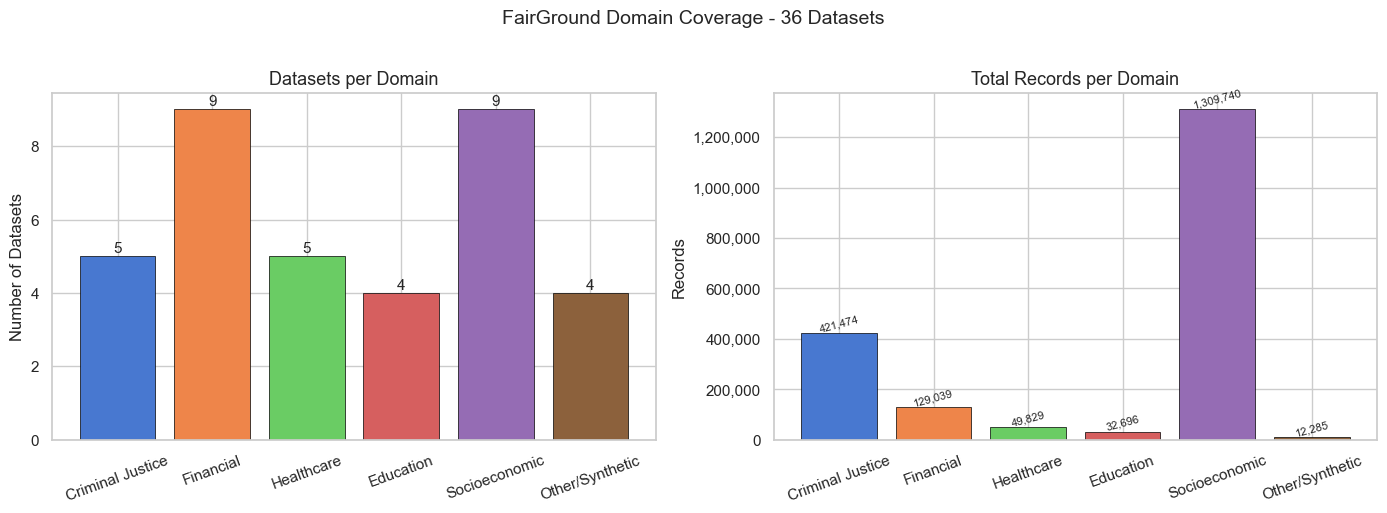

In [4]:
domain_stats = df.groupby('domain').agg(
    n_datasets=('dataset','count'),
    total_records=('n_samples','sum')
).reindex(DOMAIN_ORDER).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = [DOMAIN_COLORS[d] for d in domain_stats['domain']]

ax1.bar(domain_stats['domain'], domain_stats['n_datasets'],
        color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Datasets per Domain', fontsize=13)
ax1.set_ylabel('Number of Datasets')
ax1.tick_params(axis='x', rotation=20)
for i, val in enumerate(domain_stats['n_datasets']):
    ax1.text(i, val + 0.1, str(int(val)), ha='center', fontsize=11)

ax2.bar(domain_stats['domain'], domain_stats['total_records'],
        color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Total Records per Domain', fontsize=13)
ax2.set_ylabel('Records')
ax2.tick_params(axis='x', rotation=20)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
for i, val in enumerate(domain_stats['total_records']):
    ax2.text(i, val + 5000, f'{int(val):,}', ha='center', fontsize=8, rotation=15)

plt.suptitle(f'FairGround Domain Coverage - {len(df)} Datasets', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_domain_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Sensitive Attributes by Domain

Note: Sensitive attribute names are normalized to lowercase for visualization. Raw names vary across datasets (for example `sex` and `SEX`, or `race`, `Race` and `RACE`) but represent the same attribute. This is a FairGround corpus characteristic, not a preprocessing choice.

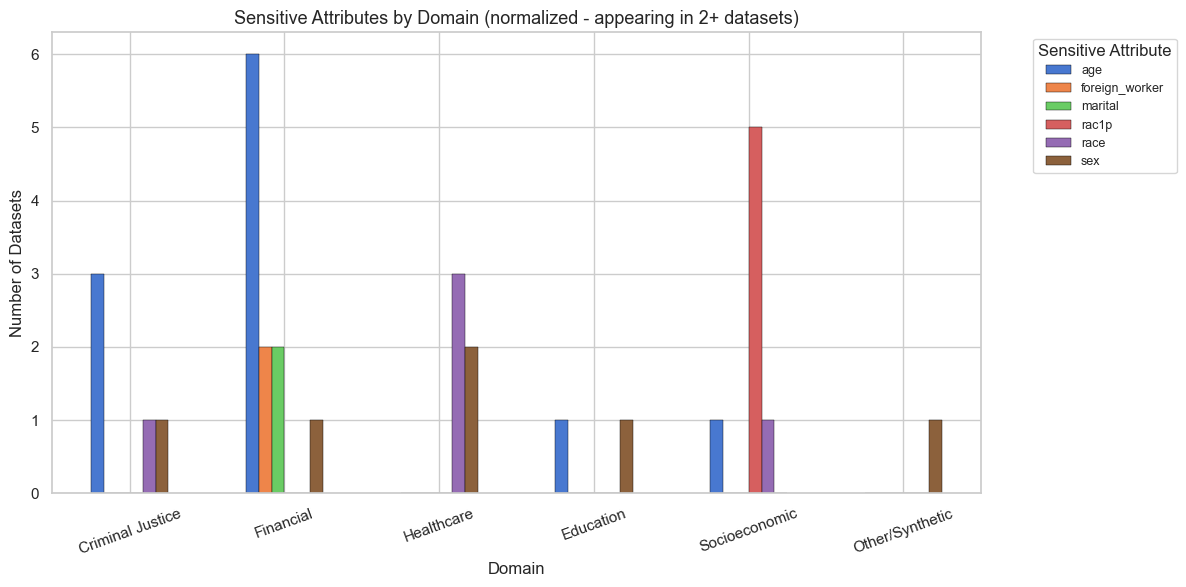

Sensitive attrs per domain (normalized):
  Criminal Justice: ['age', 'sex', 'race', 'race code cd']
  Financial: ['age', 'marital', 'foreign_worker', 'sex', '<= 25 years']
  Healthcare: ['race', 'sex']
  Education: ['racetxt', 'male', 'finance', 'sex', 'age']
  Socioeconomic: ['rac1p', 'race', 'racepctasian', 'pct12-21', 'age']
  Other/Synthetic: ['ethnicity', 's1', 'sex', 'sensible_feature']


In [5]:
# Normalize attr names to lowercase for consistent visualization
domain_attr_counts = {}
for domain in DOMAIN_ORDER:
    attrs = []
    for _, row in df[df['domain']==domain].iterrows():
        attrs.extend([a.lower().strip() for a in row['sensitive_cols']])
    domain_attr_counts[domain] = pd.Series(attrs).value_counts()

# Get all unique attrs across domains
all_norm_attrs = set()
for counts in domain_attr_counts.values():
    all_norm_attrs.update(counts.index)

# Build matrix, rows=domains, cols=attrs
matrix = pd.DataFrame(0, index=DOMAIN_ORDER, columns=sorted(all_norm_attrs))
for domain, counts in domain_attr_counts.items():
    for attr, count in counts.items():
        matrix.loc[domain, attr] = count

# Keep only attrs appearing in 2+ datasets, filter columns
cols_to_keep = matrix.columns[matrix.sum(axis=0) >= 2]
matrix_filtered = matrix[cols_to_keep]

fig, ax = plt.subplots(figsize=(12, 6))
matrix_filtered.plot(kind='bar', ax=ax,
            edgecolor='black', linewidth=0.3)
ax.set_title('Sensitive Attributes by Domain (normalized - appearing in 2+ datasets)', fontsize=13)
ax.set_xlabel('Domain')
ax.set_ylabel('Number of Datasets')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Sensitive Attribute', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_sensitive_attrs_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sensitive attrs per domain (normalized):')
for domain, counts in domain_attr_counts.items():
    print(f'  {domain}: {list(counts.index)}')

## 4. Sensitive Attribute Frequency, Top 10 Overall

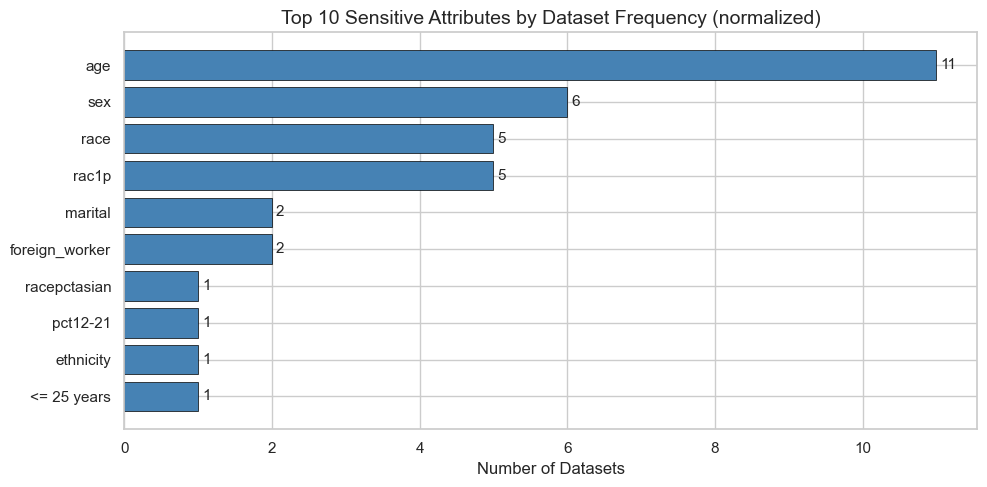

Most common after normalizing names: age (11 datasets), sex (6 datasets), race (5 datasets), rac1p (5 datasets)


In [6]:
all_attrs_norm = []
for _, row in df.iterrows():
    all_attrs_norm.extend([a.lower().strip() for a in row['sensitive_cols']])
attr_counts = pd.Series(all_attrs_norm).value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(attr_counts.index[::-1], attr_counts.values[::-1],
        color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_title('Top 10 Sensitive Attributes by Dataset Frequency (normalized)', fontsize=14)
ax.set_xlabel('Number of Datasets')
for i, (attr, val) in enumerate(zip(attr_counts.index[::-1], attr_counts.values[::-1])):
    ax.text(val + 0.05, i, str(val), va='center', fontsize=11)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_sensitive_attributes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Most common after normalizing names: ' + ', '.join(f'{attr} ({n} datasets)' for attr, n in attr_counts.head(4).items()))

## 5. Label Balance Across Datasets

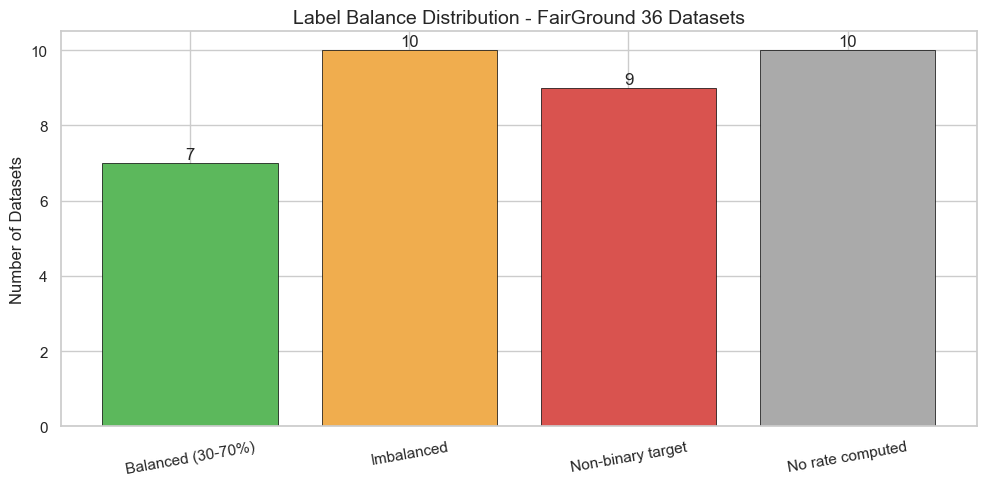

Only 17 of 36 datasets have interpretable binary rates
19 datasets have non-binary or undefined targets


In [7]:
balance_counts = df['balance'].value_counts()
balance_order = ['Balanced (30-70%)','Imbalanced','Non-binary target','No rate computed']
balance_counts = balance_counts.reindex(balance_order)

colors_map = {
    'Balanced (30-70%)': '#5cb85c',
    'Imbalanced': '#f0ad4e',
    'Non-binary target': '#d9534f',
    'No rate computed': '#aaaaaa'
}
bar_colors = [colors_map[b] for b in balance_order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(balance_counts.index, balance_counts.values,
              color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_title(f'Label Balance Distribution - FairGround {len(df)} Datasets', fontsize=14)
ax.set_ylabel('Number of Datasets')
ax.tick_params(axis='x', rotation=10)
for bar, val in zip(bars, balance_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(val)), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_label_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Only {balance_counts["Balanced (30-70%)"] + balance_counts["Imbalanced"]} of {len(df)} datasets have interpretable binary rates')
print(f'{balance_counts["Non-binary target"] + balance_counts["No rate computed"]} datasets have non-binary or undefined targets')

## 6. Feature Count Distribution

4 datasets have >200 features (arrhythmia: 279, MEPS panels: 1830-1940) and are excluded from the histogram. These high-dimensional datasets are likely to need dimensionality reduction before fairness evaluation.

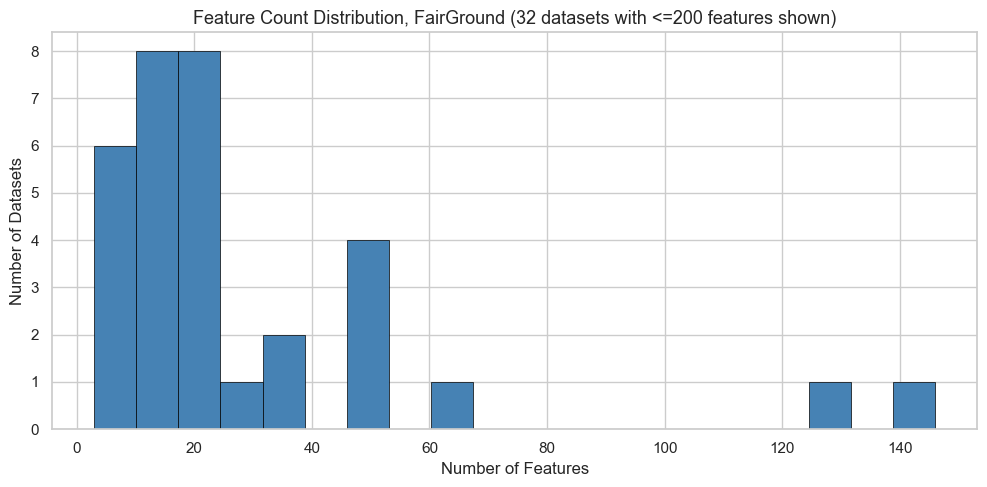

Excluded (>200 features):
  arrhythmia: 279 features
  meps_panel_19_fy2015: 1830 features
  meps_panel_20_fy2015: 1830 features
  meps_panel_21_fy2016: 1940 features
Median features (all 36): 20


In [8]:
df_plot = df[df['n_features'] <= 200].copy()
df_high = df[df['n_features'] > 200].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_plot['n_features'], bins=20, color='steelblue',
        edgecolor='black', linewidth=0.5)
ax.set_title(
    f'Feature Count Distribution, FairGround ({len(df_plot)} datasets with <=200 features shown)',
    fontsize=13)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Number of Datasets')
plt.tight_layout()
plt.savefig('../figures/eda/fairground_feature_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Excluded (>200 features):')
for _, row in df_high.iterrows():
    print(f'  {row["dataset"]}: {row["n_features"]} features')
print(f'Median features (all {len(df)}): {df["n_features"].median():.0f}')

## 7. Records per Domain by Label Balance

Key insight for fairness evaluation: which domains have usable binary classification labels, and how does record volume relate to label quality across domains.

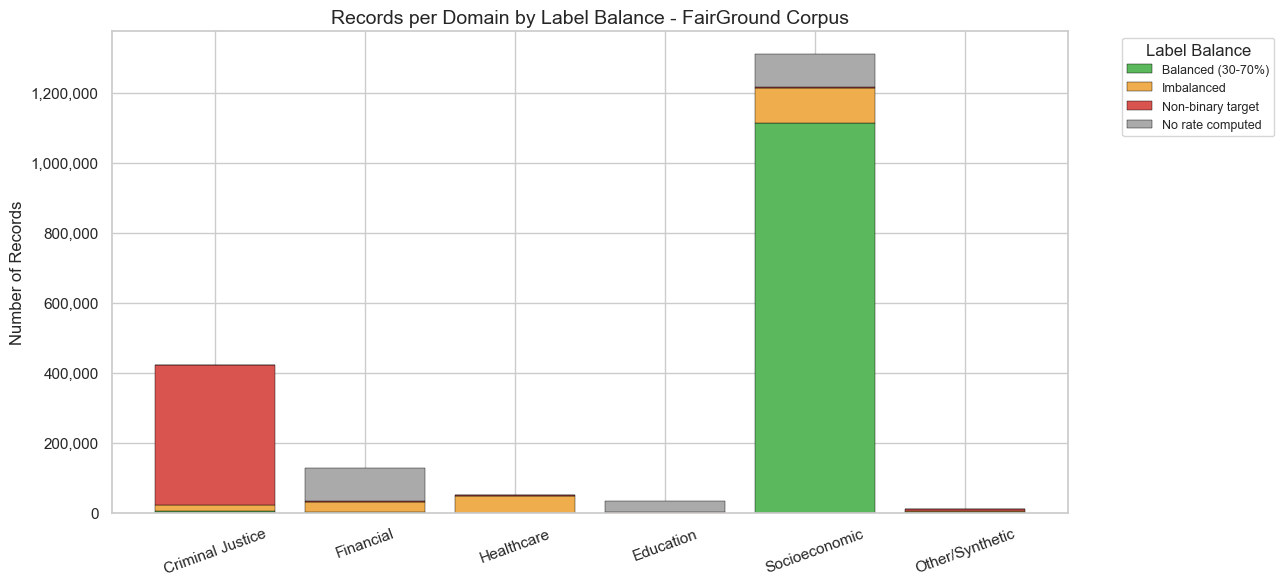

Key findings:
Socioeconomic: 1,214,546 usable binary records
Criminal Justice: 398,802 non-binary records (Chicago SSL dominates)
Healthcare: 0 balanced records; 49,378 of 49,829 are imbalanced
Education: 31,652 of 32,696 records have undefined labels


In [9]:
BALANCE_ORDER = ['Balanced (30-70%)','Imbalanced','Non-binary target','No rate computed']
BALANCE_COLORS = {
    'Balanced (30-70%)': '#5cb85c',
    'Imbalanced': '#f0ad4e',
    'Non-binary target': '#d9534f',
    'No rate computed': '#aaaaaa'
}

domain_balance = df.groupby(['domain','balance'])['n_samples'].sum().unstack(fill_value=0)
domain_balance = domain_balance.reindex(DOMAIN_ORDER)
domain_balance = domain_balance.reindex(columns=[c for c in BALANCE_ORDER if c in domain_balance.columns], fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
bottom = pd.Series([0]*len(domain_balance), index=domain_balance.index)
for balance_cat in domain_balance.columns:
    color = BALANCE_COLORS.get(balance_cat, 'steelblue')
    ax.bar(domain_balance.index, domain_balance[balance_cat],
           bottom=bottom, label=balance_cat, color=color,
           edgecolor='black', linewidth=0.3)
    bottom = bottom + domain_balance[balance_cat]

ax.set_title('Records per Domain by Label Balance - FairGround Corpus', fontsize=14)
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=20)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.legend(title='Label Balance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_records_by_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key findings:')
print(f'Socioeconomic: {domain_balance.loc["Socioeconomic","Balanced (30-70%)"] + domain_balance.loc["Socioeconomic","Imbalanced"]:,.0f} usable binary records')
print(f'Criminal Justice: {domain_balance.loc["Criminal Justice","Non-binary target"]:,.0f} non-binary records (Chicago SSL dominates)')
healthcare, education = domain_balance.loc['Healthcare'], domain_balance.loc['Education']
print(f"Healthcare: {healthcare.get('Balanced (30-70%)', 0):,.0f} balanced records; {healthcare['Imbalanced']:,.0f} of {healthcare.sum():,.0f} are imbalanced")
print(f"Education: {education['No rate computed']:,.0f} of {education.sum():,.0f} records have undefined labels")

## 8. Top 10 Largest Datasets

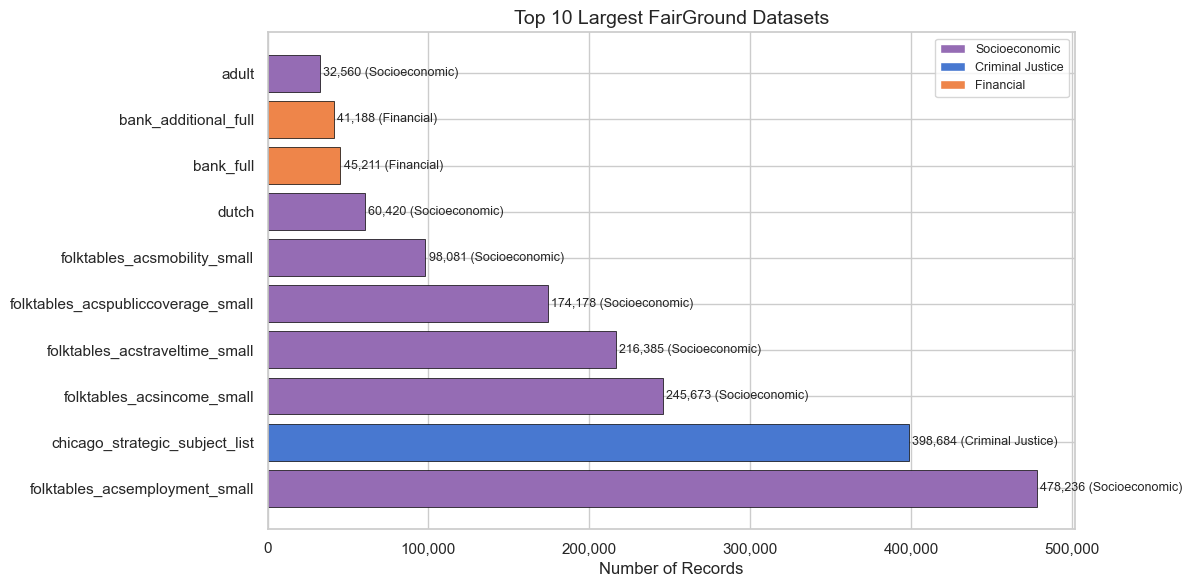

In [10]:
top10 = df.nlargest(10, 'n_samples').copy()

fig, ax = plt.subplots(figsize=(12, 6))
colors = [DOMAIN_COLORS[d] for d in top10['domain']]
bars = ax.barh(top10['dataset'], top10['n_samples'],
               color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Top 10 Largest FairGround Datasets', fontsize=14)
ax.set_xlabel('Number of Records')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{row["n_samples"]:,} ({row["domain"]})', va='center', fontsize=9)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=DOMAIN_COLORS[d], label=d)
                   for d in top10['domain'].unique()]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_top10_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Key Observations

**Corpus composition:** 36 datasets across 6 domains. Socioeconomic (9) and Financial (9) are most represented by dataset count. Socioeconomic dominates by record count, 1,309,740 records (67%) driven by folktables variants.

**Size imbalance:** Dataset sizes range from 118 (Ricci) to 478,236 (folktables_acsemployment_small). Top 5 datasets account for the majority of total records.

**Sensitive attribute inconsistency:** Age is the most common sensitive attribute (11 datasets). Naming is inconsistent for other attributes: sex appears as `sex` and `SEX`, and race-related attributes appear in 10+ datasets under different names (RAC1P, race, Race, RACE, racetxt). This is a known FairGround corpus characteristic.

**Label quality:** Only 17 of 36 datasets have interpretable binary classification rates. 9 datasets have non-binary or continuous targets requiring special handling in Stage 2. 10 datasets have undefined rates.

**Domain label quality varies critically:** Socioeconomic has 1,214,546 usable binary records, the most of any domain. Criminal Justice has 398,802 non-binary records (dominated by Chicago Strategic Subject List). Healthcare has no balanced datasets: 49,378 of its 49,829 records are imbalanced. Education has undefined labels for 31,652 of its 32,696 records. These domain-level label quality differences directly affect Stage 2 fairness metric computation.

**Benchmark monoculture addressed:** FairGround's cross-domain coverage directly responds to Ding et al. (2021)'s critique of over-reliance on legacy datasets like Adult and COMPAS.